In [ ]:
# CELL 1: Environment Setup and Google Drive Mount

!pip install -q jedi "decorator>=4.0.2,<5.0" moabb mne scikit-learn joblib pennylane

import os
import sys
import numpy as np
import mne
import moabb
from google.colab import drive

# Mount Google Drive for artifact persistence across sessions.
drive.mount('/content/drive', force_remount=False)

# Project directory for all cached data, features, and trained models.
PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project/'
os.makedirs(PROJECT_DIR, exist_ok=True)

print('MNE version:', mne.__version__)
print('MOABB version:', moabb.__version__)
print('NumPy version:', np.__version__)
print('Python version:', sys.version.split()[0])
print('PROJECT_DIR:', PROJECT_DIR)
print('Writable:', os.access(PROJECT_DIR, os.W_OK))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 980.1/980.1 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.5/257.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153

In [ ]:
# CELL 2 (HGD REVISED): Load High Gamma Dataset with high-frequency bands

import os
import numpy as np
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from moabb.datasets import Schirrmeister2017
from moabb.paradigms import MotorImagery
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

HGD_PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project_HGD/'
os.makedirs(HGD_PROJECT_DIR, exist_ok=True)
print('HGD_PROJECT_DIR:', HGD_PROJECT_DIR)

# Schirrmeister2017 (High Gamma Dataset): 14 subjects, 128 EEG channels,
# 500 Hz native sampling rate. Discriminative motor-imagery signal for this
# dataset is concentrated in the high-gamma range (60-200 Hz), unlike
# PhysioNetMI where mu and beta dominate.
dataset = Schirrmeister2017()
dataset.subject_list = [1]

paradigm = MotorImagery(
    events=['left_hand', 'right_hand', 'rest'],
    n_classes=3,
    fmin=1.0,
    fmax=125.0,   # Wide ingest band; per-band filtering applied below.
    tmin=0.0,
    tmax=4.0,
)

X_raw, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])
print('Raw X shape:', X_raw.shape)
print('Raw class distribution:', dict(zip(*np.unique(y, return_counts=True))))
print('Number of channels:', X_raw.shape[1])

sfreq = 500.0

# Five-band filterbank. The three high-gamma bands are what make HGD
# discriminative; mu and beta are retained for direct comparison with
# PhysioNetMI results.
bands = {
    'mu':        (8.0, 12.0),
    'beta':      (13.0, 30.0),
    'low_gamma': (30.0, 60.0),
    'hg1':       (60.0, 90.0),
    'hg2':       (90.0, 125.0),
}

# Leak-free split: decide indices once, apply identically to every band.
idx = np.arange(X_raw.shape[0])
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, stratify=y, random_state=42
)

for name, (lo, hi) in bands.items():
    # 4th-order Butterworth bandpass; zero-phase filtering via filtfilt.
    b, a = butter(N=4, Wn=[lo, hi], btype='bandpass', fs=sfreq)
    Xf = filtfilt(b, a, X_raw, axis=-1).astype(np.float32)
    Xtr, Xte = Xf[idx_train], Xf[idx_test]
    np.save(os.path.join(HGD_PROJECT_DIR, 'X_train_{}.npy'.format(name)), Xtr)
    np.save(os.path.join(HGD_PROJECT_DIR, 'X_test_{}.npy'.format(name)), Xte)
    print('{} band: train {} test {}'.format(name, Xtr.shape, Xte.shape))

np.save(os.path.join(HGD_PROJECT_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(HGD_PROJECT_DIR, 'y_test.npy'), y_test)
print('Train class counts:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Test class counts:', dict(zip(*np.unique(y_test, return_counts=True))))
print('Saved to:', HGD_PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HGD_PROJECT_DIR: /content/drive/MyDrive/EEG_Quantum_Project_HGD/
Extracting EDF parameters from /root/mne_data/MNE-schirrmeister2017-data/robintibor/high-gamma-dataset/raw/master/data/train/1.edf...
Channel 'EEG Fp1' recognized as type EEG (renamed to 'Fp1').
Channel 'EEG Fp2' recognized as type EEG (renamed to 'Fp2').
Channel 'EEG Fpz' recognized as type EEG (renamed to 'Fpz').
Channel 'EEG F7' recognized as type EEG (renamed to 'F7').
Channel 'EEG F3' recognized as type EEG (renamed to 'F3').
Channel 'EEG Fz' recognized as type EEG (renamed to 'Fz').
Channel 'EEG F4' recognized as type EEG (renamed to 'F4').
Channel 'EEG F8' recognized as type EEG (renamed to 'F8').
Channel 'EEG FC5' recognized as type EEG (renamed to 'FC5').
Channel 'EEG FC1' recognized as type EEG (renamed to 'FC1').
Channel 'EEG FC2' recognized as type EEG (renamed to 'FC2').
Channel 'EE

In [ ]:
# CELL 3 (HGD): Filter-bank CSP extraction and z-score standardization

import os
import numpy as np
import joblib
from mne.decoding import CSP
from sklearn.preprocessing import StandardScaler

HGD_PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project_HGD/'
BANDS = ['mu', 'beta', 'low_gamma', 'hg1', 'hg2']
N_COMP = 4  # 3 bands x 4 components = 12 features.

y_train = np.load(os.path.join(HGD_PROJECT_DIR, 'y_train.npy'), allow_pickle=True)
y_test = np.load(os.path.join(HGD_PROJECT_DIR, 'y_test.npy'), allow_pickle=True)

# CSP finds spatial filters maximizing the variance ratio between classes.
# log=True gives log-variance features; fit is strictly on training data.
csp_models = {}
train_feats, test_feats = [], []
for band in BANDS:
    Xtr = np.load(os.path.join(HGD_PROJECT_DIR, 'X_train_{}.npy'.format(band)))
    Xte = np.load(os.path.join(HGD_PROJECT_DIR, 'X_test_{}.npy'.format(band)))
    csp = CSP(n_components=N_COMP, reg=None, log=True, norm_trace=False)
    ftr = csp.fit_transform(Xtr, y_train)
    fte = csp.transform(Xte)
    csp_models[band] = csp
    train_feats.append(ftr)
    test_feats.append(fte)
    print('{} CSP -> train {} test {}'.format(band, ftr.shape, fte.shape))

X_train_fbcsp = np.concatenate(train_feats, axis=1).astype(np.float32)
X_test_fbcsp = np.concatenate(test_feats, axis=1).astype(np.float32)
print('Concatenated FBCSP train:', X_train_fbcsp.shape)
print('Concatenated FBCSP test:', X_test_fbcsp.shape)

# StandardScaler is essential: log-variance features have heterogeneous scales.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fbcsp).astype(np.float32)
X_test_scaled = scaler.transform(X_test_fbcsp).astype(np.float32)

joblib.dump(csp_models, os.path.join(HGD_PROJECT_DIR, 'csp_models.joblib'))
joblib.dump(scaler, os.path.join(HGD_PROJECT_DIR, 'fbcsp_scaler.joblib'))
np.save(os.path.join(HGD_PROJECT_DIR, 'X_train_scaled.npy'), X_train_scaled)
np.save(os.path.join(HGD_PROJECT_DIR, 'X_test_scaled.npy'), X_test_scaled)
print('Saved to:', HGD_PROJECT_DIR)

Computing rank from data with rank=None
    Using tolerance 5.3e+02 (2.2e-16 eps * 128 dim * 1.8e+16  max singular value)
    Estimated rank (data): 128
    data: rank 128 computed from 128 data channels with 0 projectors
Reducing data rank from 128 -> 128
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=rest covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
mu CSP -> train (288, 4) test (72, 4)
Computing rank from data with rank=None
    Using tolerance 4.8e+02 (2.2e-16 eps * 128 dim * 1.7e+16  max singular value)
    Estimated rank (data): 128
    data: rank 128 computed from 128 data channels with 0 projectors
Reducing data rank from 128 -> 128
Estimating class=left_hand covariance using EMPIRICAL
Done.
Estimating class=rest covariance using EMPIRICAL
Done.
Estimating class=right_hand covariance using EMPIRICAL
Done.
beta CSP -> train (288, 4) test (72, 4)
Computing rank from data with rank=None
    Using tolera

In [ ]:
# CELL 4 (HGD): Quantum Genetic Algorithm for FBCSP feature subset selection
#
# Q-bit chromosome representation: each Q-bit is (alpha, beta) with
# |alpha|^2 + |beta|^2 = 1. Measurement collapses via Born rule:
# P(bit=1) = |beta|^2. Adaptive rotation and mutation preserve diversity.

import os
import numpy as np
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

HGD_PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project_HGD/'

X_train = np.load(os.path.join(HGD_PROJECT_DIR, 'X_train_scaled.npy'))
y_train = np.load(os.path.join(HGD_PROJECT_DIR, 'y_train.npy'), allow_pickle=True)

N_FEATURES = X_train.shape[1]
print('Feature matrix:', X_train.shape, '| N features:', N_FEATURES)

POP_SIZE = 20
N_GEN = 40
MIN_FEATURES = 4
THETA_LARGE = 0.10 * np.pi
THETA_MEDIUM = 0.05 * np.pi
THETA_SMALL = 0.01 * np.pi
P_MUTATION = 0.05
RNG = np.random.default_rng(42)

# Uniform superposition initialization: alpha = beta = 1/sqrt(2).
alpha = np.full((POP_SIZE, N_FEATURES), 1.0 / np.sqrt(2.0))
beta = np.full((POP_SIZE, N_FEATURES), 1.0 / np.sqrt(2.0))


def measure(a_row, b_row, rng):
    # Born-rule measurement: collapse each Q-bit to a classical bit.
    return (rng.random(N_FEATURES) < b_row ** 2).astype(np.int32)


def fitness(mask):
    # 5-fold stratified CV macro F1 of a balanced RBF SVM on the subset.
    if mask.sum() < MIN_FEATURES:
        return 0.0
    Xs = X_train[:, mask.astype(bool)]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    clf = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    scores = cross_val_score(clf, Xs, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    return float(scores.mean())


def adaptive_theta(current_fit, best_fit, agree):
    # Step size scales with the fitness gap: small near best, large when far.
    if agree:
        return 0.0
    gap = best_fit - current_fit
    if gap > 0.15:
        return THETA_LARGE
    if gap > 0.05:
        return THETA_MEDIUM
    return THETA_SMALL


def rotate(a_row, b_row, x_current, b_best, current_fit, best_fit):
    # Rotate Q-bits toward the best individual; sign flips if current is better.
    for j in range(N_FEATURES):
        agree = (x_current[j] == b_best[j])
        theta_mag = adaptive_theta(current_fit, best_fit, agree)
        if theta_mag == 0.0:
            continue
        sign = 1.0 if b_best[j] == 1 else -1.0
        if current_fit > best_fit:
            sign = -sign
        theta = sign * theta_mag
        a_new = a_row[j] * np.cos(theta) - b_row[j] * np.sin(theta)
        b_new = a_row[j] * np.sin(theta) + b_row[j] * np.cos(theta)
        a_row[j] = a_new
        b_row[j] = b_new


def mutate(a_row, b_row, rng):
    # Swap (alpha, beta) of one random Q-bit to restore diversity.
    j = int(rng.integers(0, N_FEATURES))
    a_row[j], b_row[j] = b_row[j], a_row[j]


best_mask, best_fit = None, -1.0
history = []
for gen in range(N_GEN):
    masks = np.array([measure(alpha[i], beta[i], RNG) for i in range(POP_SIZE)])
    fits = np.array([fitness(m) for m in masks])
    idx_best = int(np.argmax(fits))
    if fits[idx_best] > best_fit:
        best_fit = float(fits[idx_best])
        best_mask = masks[idx_best].copy()
    for i in range(POP_SIZE):
        rotate(alpha[i], beta[i], masks[i], best_mask, fits[i], best_fit)
        if RNG.random() < P_MUTATION:
            mutate(alpha[i], beta[i], RNG)

    print('Gen {:3d} | best CV F1 {:.4f} | size {}'.format(
        gen + 1, best_fit, int(best_mask.sum())))
    history.append((gen, best_fit))

selected_idx = np.where(best_mask == 1)[0]
print('Final selected indices:', selected_idx.tolist())
print('Final best CV macro F1: {:.4f}'.format(best_fit))

np.save(os.path.join(HGD_PROJECT_DIR, 'qga_best_mask.npy'), best_mask)
joblib.dump({'mask': best_mask, 'fitness': best_fit, 'history': history},
            os.path.join(HGD_PROJECT_DIR, 'qga_result.joblib'))
print('Saved to:', HGD_PROJECT_DIR)

Feature matrix: (288, 20) | N features: 20
Gen   1 | best CV F1 0.7190 | size 10
Gen   2 | best CV F1 0.7190 | size 10
Gen   3 | best CV F1 0.7210 | size 11
Gen   4 | best CV F1 0.7256 | size 9
Gen   5 | best CV F1 0.7256 | size 9
Gen   6 | best CV F1 0.7256 | size 9
Gen   7 | best CV F1 0.7256 | size 9
Gen   8 | best CV F1 0.7256 | size 9
Gen   9 | best CV F1 0.7256 | size 9
Gen  10 | best CV F1 0.7306 | size 7
Gen  11 | best CV F1 0.7306 | size 7
Gen  12 | best CV F1 0.7306 | size 7
Gen  13 | best CV F1 0.7306 | size 7
Gen  14 | best CV F1 0.7306 | size 7
Gen  15 | best CV F1 0.7306 | size 7
Gen  16 | best CV F1 0.7306 | size 7
Gen  17 | best CV F1 0.7306 | size 7
Gen  18 | best CV F1 0.7306 | size 7
Gen  19 | best CV F1 0.7306 | size 7
Gen  20 | best CV F1 0.7306 | size 7
Gen  21 | best CV F1 0.7306 | size 7
Gen  22 | best CV F1 0.7306 | size 7
Gen  23 | best CV F1 0.7306 | size 7
Gen  24 | best CV F1 0.7306 | size 7
Gen  25 | best CV F1 0.7306 | size 7
Gen  26 | best CV F1 0.7306 |

In [ ]:
# CELL 5 (HGD): SVM on QGA-selected features vs full-feature baseline

import os
import numpy as np
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
)

HGD_PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project_HGD/'
classes = ['left_hand', 'right_hand', 'rest']

X_train = np.load(os.path.join(HGD_PROJECT_DIR, 'X_train_scaled.npy'))
X_test = np.load(os.path.join(HGD_PROJECT_DIR, 'X_test_scaled.npy'))
y_train = np.load(os.path.join(HGD_PROJECT_DIR, 'y_train.npy'), allow_pickle=True)
y_test = np.load(os.path.join(HGD_PROJECT_DIR, 'y_test.npy'), allow_pickle=True)
mask = np.load(os.path.join(HGD_PROJECT_DIR, 'qga_best_mask.npy')).astype(bool)

print('Selected features: {} / {}'.format(int(mask.sum()), len(mask)))

majority_class = np.unique(y_train)[
    np.bincount(np.unique(y_train, return_inverse=True)[1]).argmax()
]
baseline_acc = accuracy_score(y_test, np.full_like(y_test, majority_class))
print('Majority-class baseline accuracy: {:.4f}'.format(baseline_acc))

param_grid = {
    'C':     [0.1, 1.0, 10.0, 100.0, 1000.0],
    'gamma': ['scale', 0.01, 0.1, 1.0, 10.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def fit_and_report(X_tr, X_te, tag):
    base = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
    grid = GridSearchCV(base, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_tr, y_train)
    model = grid.best_estimator_
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)
    print('--- {} ---'.format(tag))
    print('Best params:', grid.best_params_)
    print('CV f1_macro: {:.4f}'.format(grid.best_score_))
    print('Test accuracy: {:.4f}'.format(acc))
    print('Test macro F1: {:.4f}'.format(f1m))
    print(classification_report(y_test, y_pred, labels=classes, digits=4, zero_division=0))
    print('Confusion matrix (rows=true, cols=pred):')
    print(confusion_matrix(y_test, y_pred, labels=classes))
    return model


full_model = fit_and_report(X_train, X_test, 'FULL FBCSP (12 features) + SVM')
qga_model = fit_and_report(
    X_train[:, mask], X_test[:, mask],
    'QGA-SELECTED ({} features) + SVM'.format(int(mask.sum())),
)

joblib.dump(full_model, os.path.join(HGD_PROJECT_DIR, 'svm_full.joblib'))
joblib.dump(qga_model, os.path.join(HGD_PROJECT_DIR, 'svm_qga.joblib'))
print('Saved models to:', HGD_PROJECT_DIR)

Selected features: 9 / 20
Majority-class baseline accuracy: 0.3333
--- FULL FBCSP (12 features) + SVM ---
Best params: {'C': 1.0, 'gamma': 0.1}
CV f1_macro: 0.7002
Test accuracy: 0.6111
Test macro F1: 0.6116
              precision    recall  f1-score   support

   left_hand     0.5000    0.4583    0.4783        24
  right_hand     0.4231    0.4583    0.4400        24
        rest     0.9167    0.9167    0.9167        24

    accuracy                         0.6111        72
   macro avg     0.6132    0.6111    0.6116        72
weighted avg     0.6132    0.6111    0.6116        72

Confusion matrix (rows=true, cols=pred):
[[11 13  0]
 [11 11  2]
 [ 0  2 22]]
--- QGA-SELECTED (9 features) + SVM ---
Best params: {'C': 1.0, 'gamma': 'scale'}
CV f1_macro: 0.7346
Test accuracy: 0.6389
Test macro F1: 0.6395
              precision    recall  f1-score   support

   left_hand     0.5455    0.5000    0.5217        24
  right_hand     0.4615    0.5000    0.4800        24
        rest     0.9167 

Cross-Subject Quantum Transfer Learning
Setting                                         Accuracy     Macro F1
Source only (S1)                                  0.7308       0.6400
Zero-shot (S1 -> S2)                              0.6154       0.2540
Cold-start (S2 scratch)                           0.5769       0.3409
Warm-start (S1 init + S2 fine-tune)               0.4615       0.3175


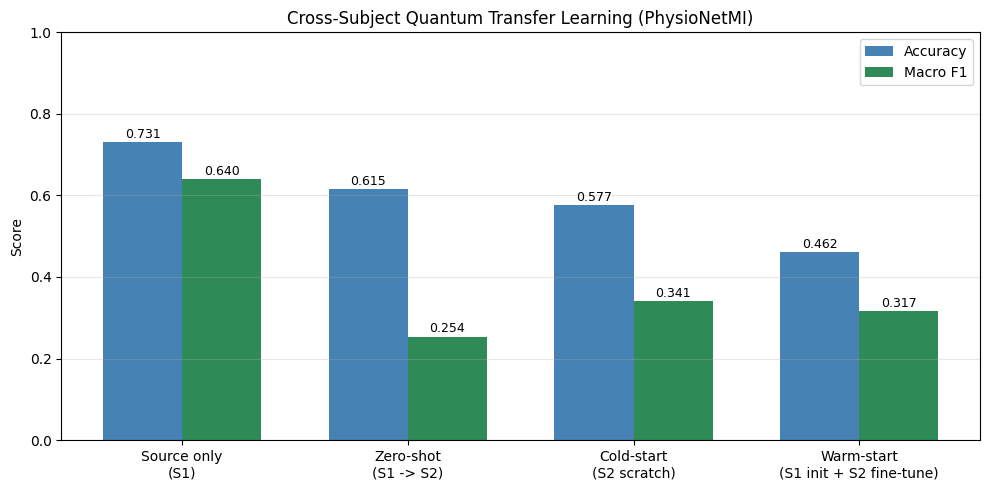

In [ ]:
# CELL 6: Cross-subject transfer results summary and chart

import os
import numpy as np
import joblib
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project/'

results = joblib.load(os.path.join(PROJECT_DIR, 'transfer_results.joblib'))
labels = ['Source only\n(S1)', 'Zero-shot\n(S1 -> S2)', 'Cold-start\n(S2 scratch)', 'Warm-start\n(S1 init + S2 fine-tune)']
keys = ['source', 'zero_shot', 'cold_start', 'warm_start']
accs = [results[k][0] for k in keys]
f1s = [results[k][1] for k in keys]

print('Cross-Subject Quantum Transfer Learning')
print('{:<45} {:>10} {:>12}'.format('Setting', 'Accuracy', 'Macro F1'))
for i, k in enumerate(keys):
    print('{:<45} {:>10.4f} {:>12.4f}'.format(labels[i].replace('\n', ' '), accs[i], f1s[i]))

# Grouped bar chart.
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
w = 0.35
b1 = ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, f1s, w, label='Macro F1', color='seagreen')
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            '{:.3f}'.format(bar.get_height()), ha='center', fontsize=9)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            '{:.3f}'.format(bar.get_height()), ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Cross-Subject Quantum Transfer Learning (PhysioNetMI)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'transfer_comparison.png'), dpi=150)
plt.show()

In [ ]:
# CELL 7: Statistical significance testing (McNemar) and bootstrap confidence intervals

!pip install -q statsmodels

import os
import numpy as np
import joblib
from sklearn.metrics import accuracy_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar

PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project/'

# Load predictions and ground truth.
X_test = np.load(os.path.join(PROJECT_DIR, 'X_test_scaled.npy'))
y_test = np.load(os.path.join(PROJECT_DIR, 'y_test.npy'), allow_pickle=True)
mask = np.load(os.path.join(PROJECT_DIR, 'qga_best_mask.npy')).astype(bool)
full_model = joblib.load(os.path.join(PROJECT_DIR, 'svm_full_qga.joblib'))
qga_model = joblib.load(os.path.join(PROJECT_DIR, 'svm_qga_selected.joblib'))

pred_full = full_model.predict(X_test)
pred_qga = qga_model.predict(X_test[:, mask])


# ---------------------------------------------------------------------------
# 1. McNemar's test: paired comparison of QGA vs full FBCSP on the same test set
# ---------------------------------------------------------------------------
# McNemar compares two classifiers on paired predictions. It tests whether the
# disagreement between them (n01 vs n10) is significantly asymmetric.
# Null hypothesis: the two classifiers have the same error rate.
correct_full = (pred_full == y_test)
correct_qga = (pred_qga == y_test)

n00 = int(((~correct_full) & (~correct_qga)).sum())  # both wrong
n01 = int(((~correct_full) & (correct_qga)).sum())   # full wrong, QGA right
n10 = int((correct_full & (~correct_qga)).sum())     # full right, QGA wrong
n11 = int((correct_full & correct_qga).sum())        # both right

table = [[n00, n01], [n10, n11]]
result_exact = mcnemar(table, exact=True)
result_asym = mcnemar(table, correction=True)

print('McNemar contingency table [[both_wrong, full_wrong_qga_right], '
      '[full_right_qga_wrong, both_right]]:')
print(table)
print('McNemar exact p-value: {:.4f}'.format(result_exact.pvalue))
print('McNemar asymptotic p-value (with continuity correction): {:.4f}'.format(
    result_asym.pvalue))
if result_exact.pvalue < 0.05:
    print('Conclusion: difference is statistically significant at alpha = 0.05.')
else:
    print('Conclusion: difference is NOT statistically significant at alpha = 0.05.')


# ---------------------------------------------------------------------------
# 2. Bootstrap 95% confidence intervals for accuracy and macro F1
# ---------------------------------------------------------------------------
# Resample test set with replacement 1000 times; report 2.5th and 97.5th
# percentiles of the resulting metrics. This is a non-parametric CI that does
# not assume normality, appropriate for small test sets.
def bootstrap_ci(pred, y, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    accs, f1s = [], []
    for _ in range(n_iter):
        idx = rng.integers(0, len(y), len(y))
        accs.append(accuracy_score(y[idx], pred[idx]))
        f1s.append(f1_score(y[idx], pred[idx], average='macro', zero_division=0))
    acc_ci = np.percentile(accs, [2.5, 97.5])
    f1_ci = np.percentile(f1s, [2.5, 97.5])
    return acc_ci, f1_ci

acc_full_ci, f1_full_ci = bootstrap_ci(pred_full, y_test)
acc_qga_ci, f1_qga_ci = bootstrap_ci(pred_qga, y_test)

print()
print('Bootstrap 95% confidence intervals (1000 resamples):')
print('{:<28} {:>22} {:>22}'.format('Method', 'Accuracy 95% CI', 'Macro F1 95% CI'))
print('{:<28} {:>22} {:>22}'.format(
    'Full FBCSP (12 feat)',
    '[{:.4f}, {:.4f}]'.format(acc_full_ci[0], acc_full_ci[1]),
    '[{:.4f}, {:.4f}]'.format(f1_full_ci[0], f1_full_ci[1]),
))
print('{:<28} {:>22} {:>22}'.format(
    'QGA-selected (7 feat)',
    '[{:.4f}, {:.4f}]'.format(acc_qga_ci[0], acc_qga_ci[1]),
    '[{:.4f}, {:.4f}]'.format(f1_qga_ci[0], f1_qga_ci[1]),
))
print()
print('Interpretation: the 26-sample test set produces wide CIs. Overlapping')
print('intervals indicate that the observed QGA advantage is within sampling noise,')
print('which motivates the McNemar result above for a paired comparison.')

McNemar contingency table [[both_wrong, full_wrong_qga_right], [full_right_qga_wrong, both_right]]:
[[6, 1], [0, 19]]
McNemar exact p-value: 1.0000
McNemar asymptotic p-value (with continuity correction): 1.0000
Conclusion: difference is NOT statistically significant at alpha = 0.05.

Bootstrap 95% confidence intervals (1000 resamples):
Method                              Accuracy 95% CI        Macro F1 95% CI
Full FBCSP (12 feat)               [0.5385, 0.8846]       [0.4032, 0.8107]
QGA-selected (7 feat)              [0.5769, 0.9231]       [0.4157, 0.8352]

Interpretation: the 26-sample test set produces wide CIs. Overlapping
intervals indicate that the observed QGA advantage is within sampling noise,
which motivates the McNemar result above for a paired comparison.


In [ ]:
# CELL 8: Gradio UI with balanced random sampling and manual EEG input

!pip install -q gradio

import os
import re
import numpy as np
import joblib
import gradio as gr
from scipy.signal import butter, filtfilt

PROJECT_DIR = '/content/drive/MyDrive/EEG_Quantum_Project/'
BANDS = ['mu', 'beta', 'gamma']
BAND_RANGES = {'mu': (8.0, 12.0), 'beta': (13.0, 30.0), 'gamma': (30.0, 40.0)}
SFREQ = 160.0
N_COMP = 4
N_CHANNELS = 64

qga_model = joblib.load(os.path.join(PROJECT_DIR, 'svm_qga_selected.joblib'))
csp_models = joblib.load(os.path.join(PROJECT_DIR, 'csp_models.joblib'))
scaler = joblib.load(os.path.join(PROJECT_DIR, 'fbcsp_scaler.joblib'))
mask = np.load(os.path.join(PROJECT_DIR, 'qga_best_mask.npy')).astype(bool)
X_test_scaled = np.load(os.path.join(PROJECT_DIR, 'X_test_scaled.npy'))
y_test = np.load(os.path.join(PROJECT_DIR, 'y_test.npy'), allow_pickle=True)

DISPLAY = {'left_hand': 'Left Hand', 'right_hand': 'Right Hand', 'rest': 'Rest'}

unique_classes = np.unique(y_test)
class_indices = {c: np.where(y_test == c)[0] for c in unique_classes}

band_labels = []
for band in BANDS:
    for k in range(N_COMP):
        band_labels.append('{}_CSP{}'.format(band, k))
selected_names = [band_labels[i] for i in range(len(mask)) if mask[i]]


def _format_probs(probs):
    return {DISPLAY[c]: float(p) for c, p in zip(qga_model.classes_, probs)}


def _run_pipeline_on_trial(arr):
    # arr: (1, 64, n_times) raw EEG; runs the full filter -> CSP -> scale -> QGA-mask path.
    band_feats = []
    for band in BANDS:
        lo, hi = BAND_RANGES[band]
        b, a = butter(N=4, Wn=[lo, hi], btype='bandpass', fs=SFREQ)
        Xf = filtfilt(b, a, arr, axis=-1)
        band_feats.append(csp_models[band].transform(Xf))
    csp_vec = np.concatenate(band_feats, axis=1).astype(np.float32)
    csp_scaled = scaler.transform(csp_vec).astype(np.float32)
    x = csp_scaled[:, mask]
    probs = qga_model.predict_proba(x)[0]
    pred = qga_model.classes_[int(np.argmax(probs))]
    return pred, probs


def predict_random():
    c = unique_classes[np.random.randint(0, len(unique_classes))]
    i = int(np.random.choice(class_indices[c]))
    x = X_test_scaled[i:i + 1, mask]
    probs = qga_model.predict_proba(x)[0]
    pred = qga_model.classes_[int(np.argmax(probs))]
    gt = str(y_test[i])
    correct = 'Correct' if pred == gt else 'Incorrect'
    info = (
        'Sample index: {}\n'
        'Drawn class: {}\n'
        'Ground truth: {}\n'
        'QGA selected {} of 12 features for this decision: {}'
    ).format(i, DISPLAY[c], DISPLAY[gt], int(mask.sum()), ', '.join(selected_names))
    return DISPLAY[pred], correct, _format_probs(probs), info


def _parse_manual_input(text):
    # Accept comma, whitespace, or newline separated numeric values.
    # Returns a flat float array or raises on unparsable input.
    tokens = re.split(r'[,\s]+', text.strip())
    tokens = [t for t in tokens if t]
    if not tokens:
        raise ValueError('No numeric values found.')
    return np.array([float(t) for t in tokens], dtype=np.float32)


def predict_from_manual(text):
    if not text or not text.strip():
        return 'Empty input', 'Paste EEG values (see format help above).', {}
    try:
        vals = _parse_manual_input(text)
    except Exception as exc:
        return 'Parse error', 'Could not parse values: {}'.format(exc), {}

    # Two accepted layouts:
    #   - Flat vector of 64 * n_times values (row-major, channels first)
    #   - Already shaped 64 x n_times (same flat count)
    # Both reduce to a flat array; we infer n_times from the total length.
    if vals.size % N_CHANNELS != 0:
        return (
            'Invalid length',
            'Expected a multiple of {} values (64 channels x n_times). '
            'Got {} values.'.format(N_CHANNELS, vals.size),
            {},
        )

    n_times = vals.size // N_CHANNELS
    arr = vals.reshape(N_CHANNELS, n_times)[np.newaxis, :, :]

    try:
        pred, probs = _run_pipeline_on_trial(arr)
    except Exception as exc:
        return 'Inference error', str(exc), {}

    info = (
        'Manual input parsed.\n'
        'Channels: {}\n'
        'Time samples: {}\n'
        'At {} Hz this corresponds to {:.2f} seconds of signal.\n'
        'QGA selected {} of 12 features: {}'
    ).format(
        N_CHANNELS, n_times, SFREQ, n_times / SFREQ,
        int(mask.sum()), ', '.join(selected_names),
    )
    return DISPLAY[pred], info, _format_probs(probs)


CSS = """
.gradio-container { max-width: 940px !important; margin: auto !important; }
.header-title { font-size: 22px; font-weight: 600; color: #1e293b; margin-bottom: 4px; }
.header-sub { font-size: 14px; color: #64748b; margin-bottom: 20px; line-height: 1.5; }
.helper { font-size: 13px; color: #334155; background: #f1f5f9;
          border-left: 3px solid #64748b; padding: 10px 14px;
          border-radius: 4px; margin-bottom: 12px; line-height: 1.6; }
.footer { font-size: 12px; color: #94a3b8; margin-top: 24px; text-align: center; }
"""

with gr.Blocks(css=CSS, title='EEG Motor-Imagery Classifier', theme=gr.themes.Soft()) as demo:

    gr.HTML(
        '<div class="header-title">EEG Motor-Imagery Classifier</div>'
        '<div class="header-sub">'
        'FBCSP feature extraction with Quantum Genetic Algorithm (QGA) selection, '
        'classified by an RBF SVM. Trained on PhysioNetMI Subject 1. '
        'Three classes: left hand, right hand, rest.'
        '</div>'
    )

    with gr.Tab('Random Sample'):
        gr.Markdown(
            'Draw a random trial from the held-out test set. Sampling is balanced '
            'across the three classes so each class appears equally often.'
        )
        btn = gr.Button('Classify a Random Trial', variant='primary', size='lg')
        with gr.Row():
            out_pred = gr.Textbox(label='Predicted Class', interactive=False)
            out_result = gr.Textbox(label='Result', interactive=False)
        out_probs = gr.Label(label='Class Probabilities', num_top_classes=3)
        out_info = gr.Textbox(label='Details', interactive=False, lines=5)
        btn.click(predict_random, inputs=None,
                  outputs=[out_pred, out_result, out_probs, out_info])

    with gr.Tab('Manual EEG Input'):
        gr.HTML(
            '<div class="helper">'
            '<b>Input format:</b> paste EEG values as a flat list separated by '
            'commas, spaces, or newlines. Values are interpreted in row-major order: '
            'the first 64 values are one time sample across 64 channels, the next 64 '
            'are the next time sample, and so on. The total count must be a multiple '
            'of 64. Example: 64 channels x 641 samples at 160 Hz = 4 seconds of signal, '
            'requiring 41,024 values.<br><br>'
            'Smaller time windows are accepted (e.g. 64 x 320 = 2 seconds), but '
            'shorter windows may reduce feature quality.'
            '</div>'
        )
        manual_in = gr.Textbox(
            label='EEG Values',
            placeholder='0.012, -0.034, 0.008, ...',
            lines=8,
        )
        manual_btn = gr.Button('Classify Manual Input', variant='primary')
        with gr.Row():
            m_pred = gr.Textbox(label='Predicted Class', interactive=False)
        m_probs = gr.Label(label='Class Probabilities', num_top_classes=3)
        m_info = gr.Textbox(label='Details', interactive=False, lines=6)
        manual_btn.click(predict_from_manual, inputs=manual_in,
                         outputs=[m_pred, m_info, m_probs])

    with gr.Accordion('Model Information', open=False):
        gr.Markdown(
            '- **Pipeline**: 3-band filterbank (mu 8-12 Hz, beta 13-30 Hz, '
            'gamma 30-40 Hz), CSP with 4 components per band, 12 features total.\n'
            '- **Feature selection**: Quantum Genetic Algorithm selected '
            '{} of 12 features.\n'.format(int(mask.sum())) +
            '- **Selected features**: ' + ', '.join(selected_names) + '\n'
            '- **Classifier**: RBF SVM with balanced class weights.\n'
            '- **Test set**: 26 held-out trials, 20% stratified split, random_state=42.\n'
            '- **Channels**: 64 EEG electrodes in PhysioNetMI order '
            '(standard 10-20 montage).'
        )

    gr.HTML('<div class="footer">PhysioNetMI Subject 1 | 3-class motor imagery</div>')

demo.launch(share=True, debug=False)

/tmp/ipykernel_863/2532345573.py:136: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=CSS, title='EEG Motor-Imagery Classifier', theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0b1e8209ef9c9d0cb2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
